In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :retina
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "QzpcVXNlcnNcTmlrb2xhalxHaXRcZ3JhcGgtZXF1aWxpYnJpdW0tcmFkaWF0aXZlLXRyYW5zZmVyXGV4YW1wbGVz"
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
using RayTraceHeatTransfer
using GeometryBasics, StaticArrays

function build_mesh(Ndim)                          # define a mesh builder function
    vertices = SVector(
        Point2(0.0, 0.0),
        Point2(1.0, 0.0),
        Point2(1.0, 1.0),
        Point2(0.0, 1.0)
    )
    solidWalls = SVector(true, true, true, true)   # all walls impenetrable by radiation

    face = PolyVolume2D{Float64}(vertices, solidWalls, 1, 1.0, 0.0)   # κ = 1, σₛ = 0 for the gas volume

    face.T_in_w  = [1000.0, 0.0, 0.0, 0.0]        # bottom hot, rest cold
    face.epsilon = [1.0, 1.0, 1.0, 1.0]            # black walls
    face.T_in_g  = -1.0                            # unknown (solve for this)
    face.q_in_g  = 0.0                             # radiative equilibrium

    mesh = RayTracingDomain2D([face], [(Ndim, Ndim)]; verbose = false)   # mesh the domain
    return mesh
end
Ndim  = 11                                         # 11 × 11 elements
mesh1 = build_mesh(Ndim);                          # build the 11 × 11 mesh

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\Nikolaj\.julia\packages\Makie\frKXt\src\scenes.jl:264


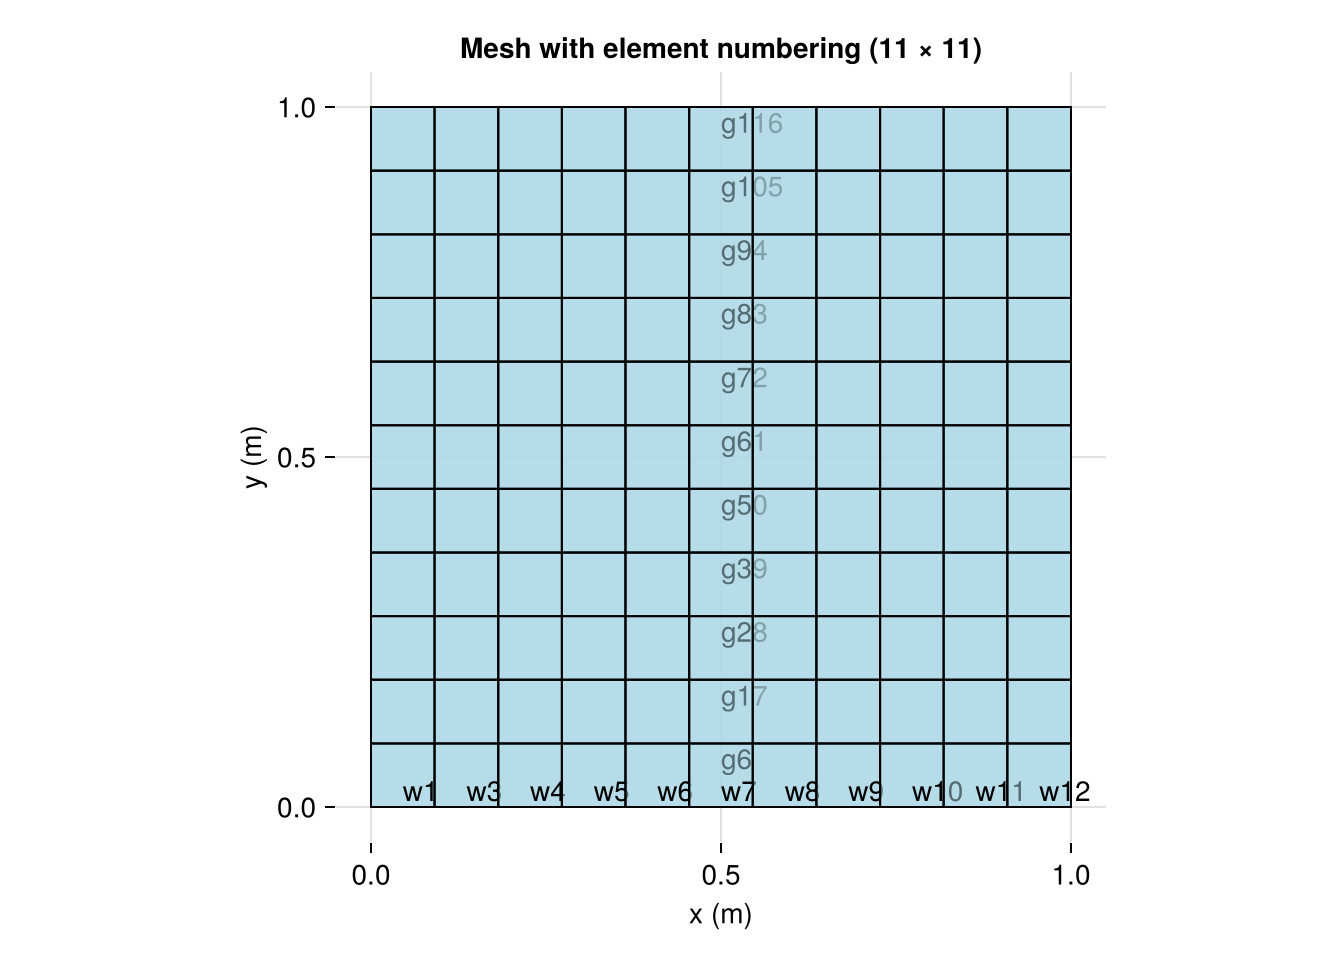

In [3]:
using CairoMakie

fig = Figure(size = (700, 700))
ax  = Axis(fig[1, 1], aspect = DataAspect(), xlabel = "x (m)", ylabel = "y (m)",
           title = "Mesh with element numbering (11 × 11)")

# Volumes are numbered row by row from the bottom, left to right within a row,
# so the volume in column c of row r has index c + (r − 1)·Ndim.
center_col = div(Ndim + 1, 2)                                          # the middle column (6 of 11)
centerline_vols = [center_col + (row - 1) * Ndim for row in 1:Ndim]    # that column's volume in every row

# Walls are numbered in the same cell order, and within a cell in the order bottom, right, top, left.
# The bottom-left corner cell owns two solid walls: its bottom edge is wall 1, its left edge wall 2.
# The remaining cells of the bottom row contribute their bottom edges as walls 3, 4, …, Ndim + 1.
bottom_wall_indices = [1; collect(3:Ndim+1)]                           # every element of the bottom (hot) wall

plotMesh(ax, mesh1)                                                     # the mesh itself
plotMesh(ax, mesh1; volumeNumbers = centerline_vols)                    # label the centreline volumes (g…)
plotMesh(ax, mesh1; wallNumbers = bottom_wall_indices)                  # label the bottom wall elements (w…)

fig

In [4]:
record_ids = [10, 20, 30]                          # optional: elements whose emitted rays are recorded for plotting
rec = RayRecorder(record_ids)                      # the ray recorder (also works in parallel)
mesh1(10^7; method = :exchange, rec = rec, verbose = false)   # ray tracing with the Sobol sampler
origins, endpoints = collect_rays(rec);            # the recorded rays, one line per ray

In [5]:
stats = smooth!(mesh1; verbose = false);           # enforce reciprocity and energy conservation on F_raw

In [6]:
all(stats.converged), maximum(stats.delta_smooth)  # did the projection converge, and the certified bound on the remaining reciprocity defect

(true, 3.0481274084910315e-15)

In [7]:
solveEquilibrium!(mesh1, mesh1.F_smooth; verbose = false)   # solve the GERT system for the steady state

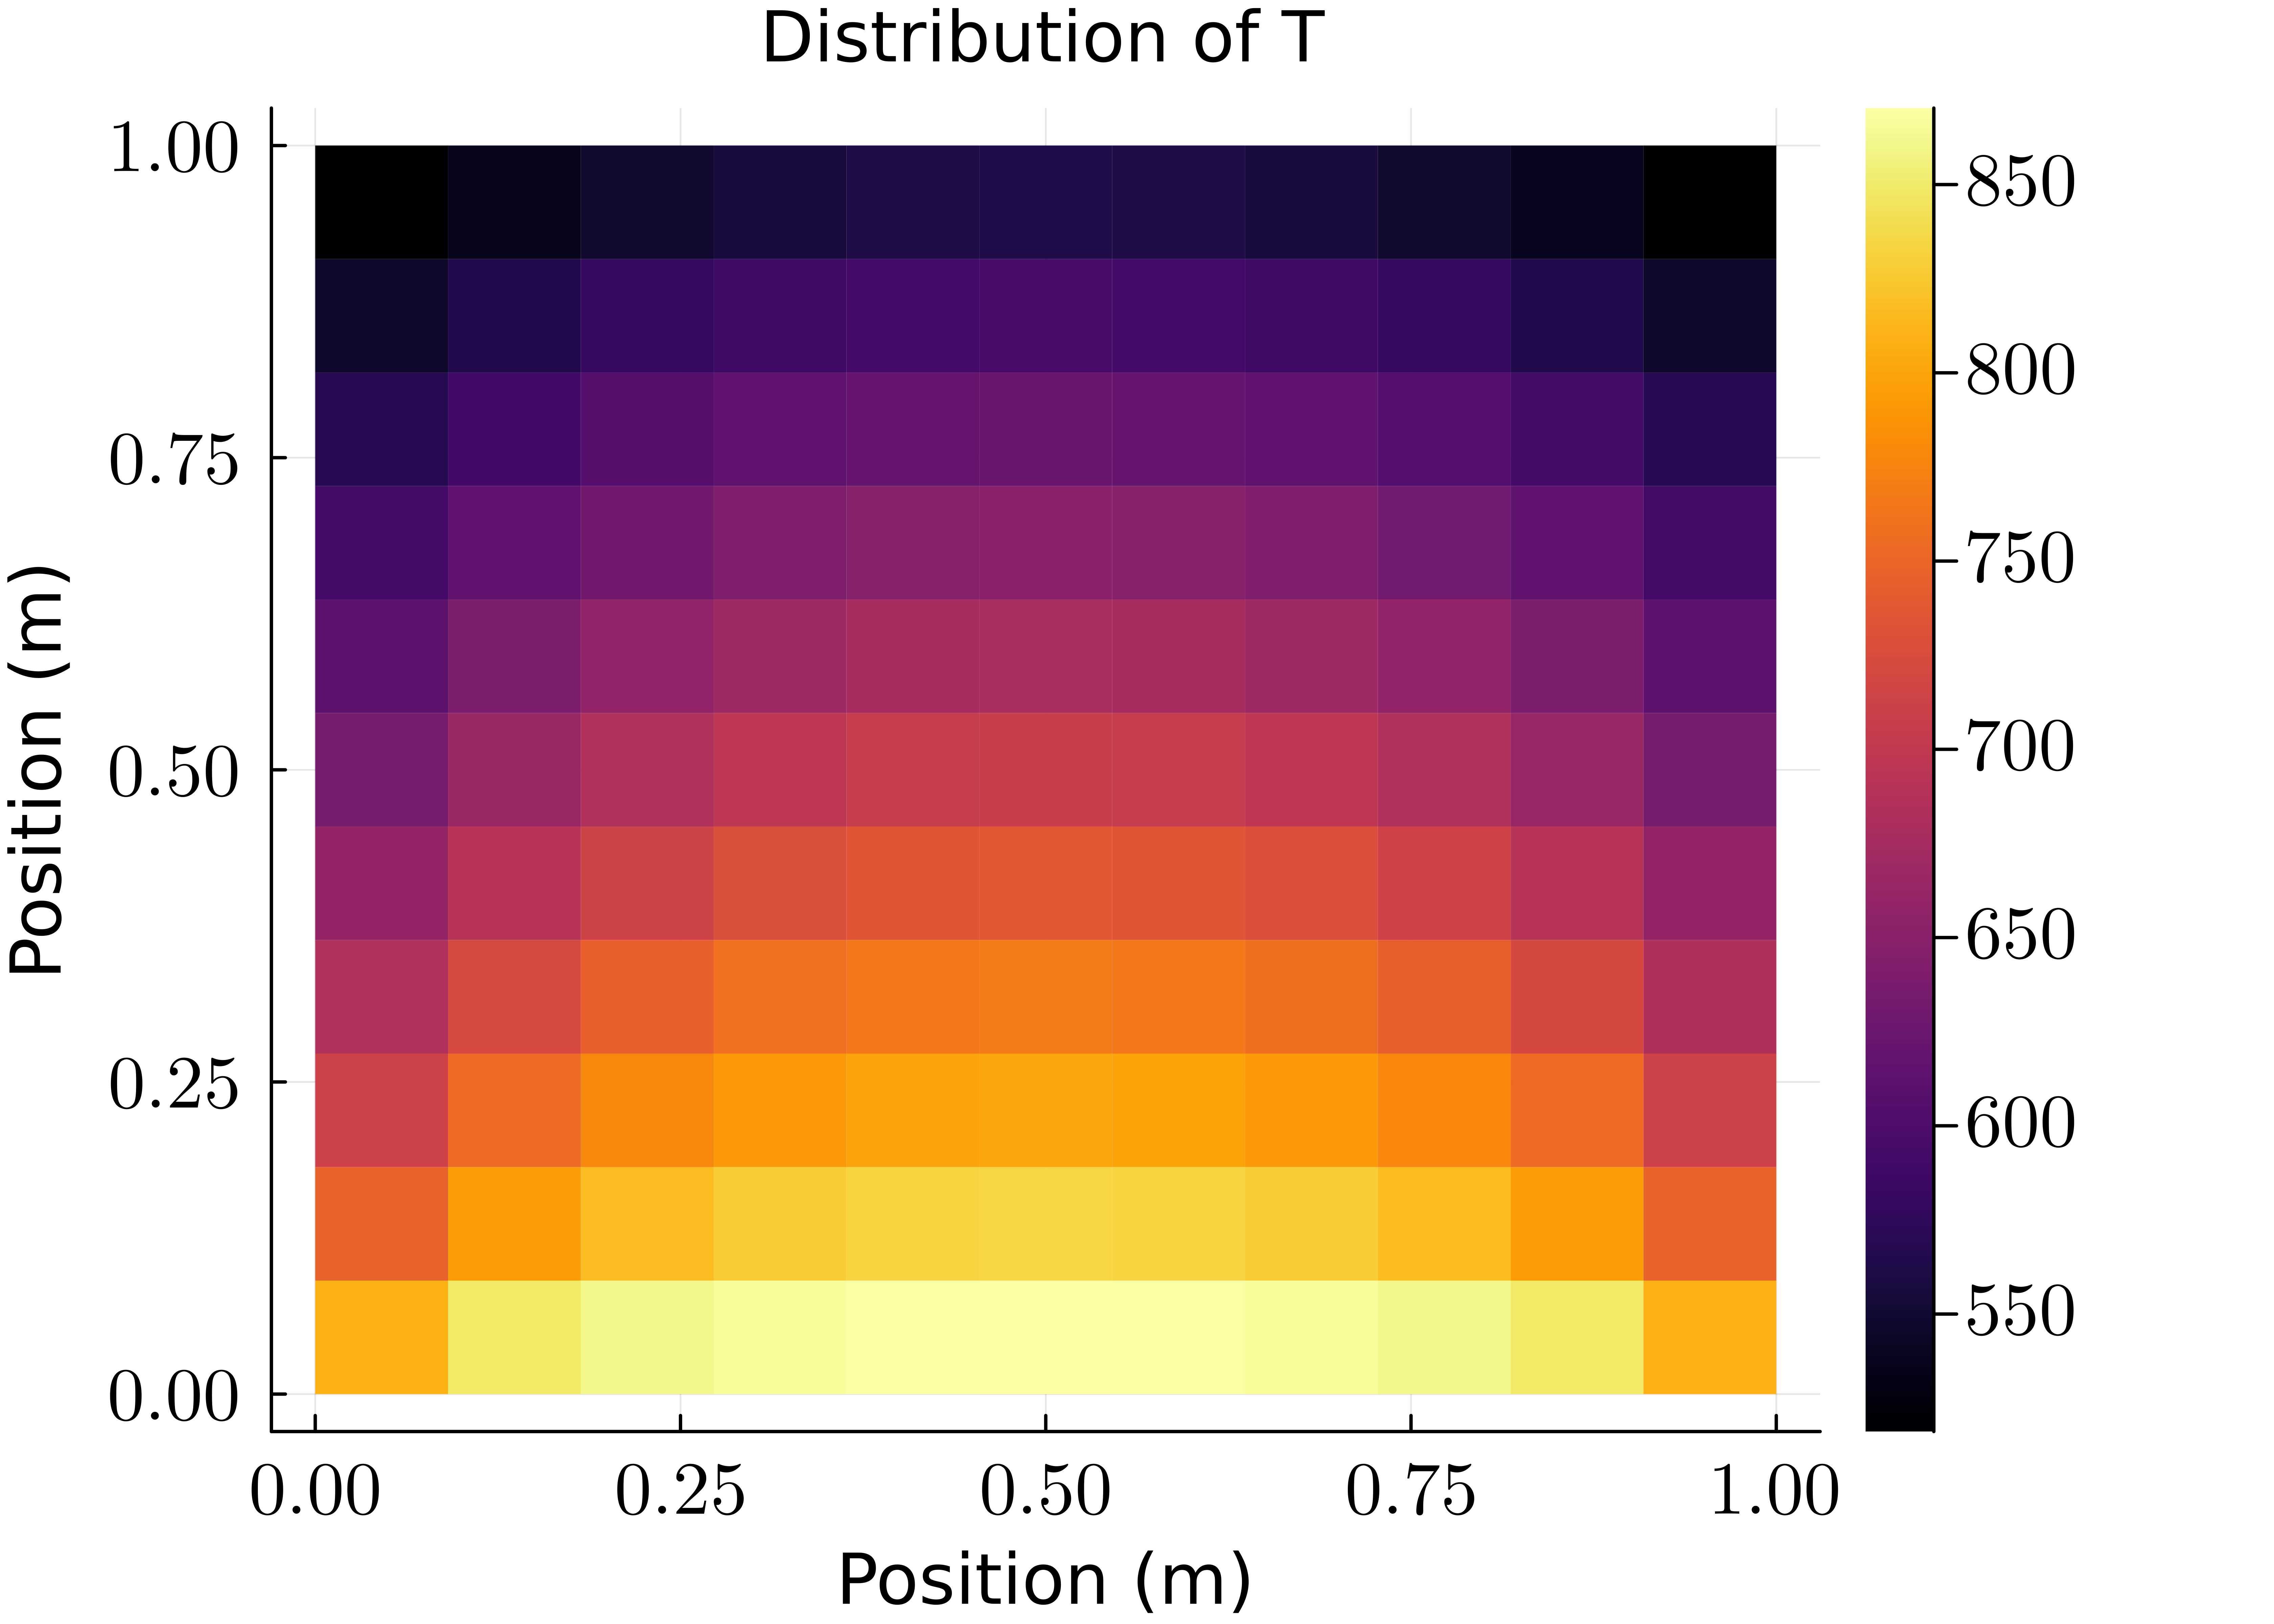

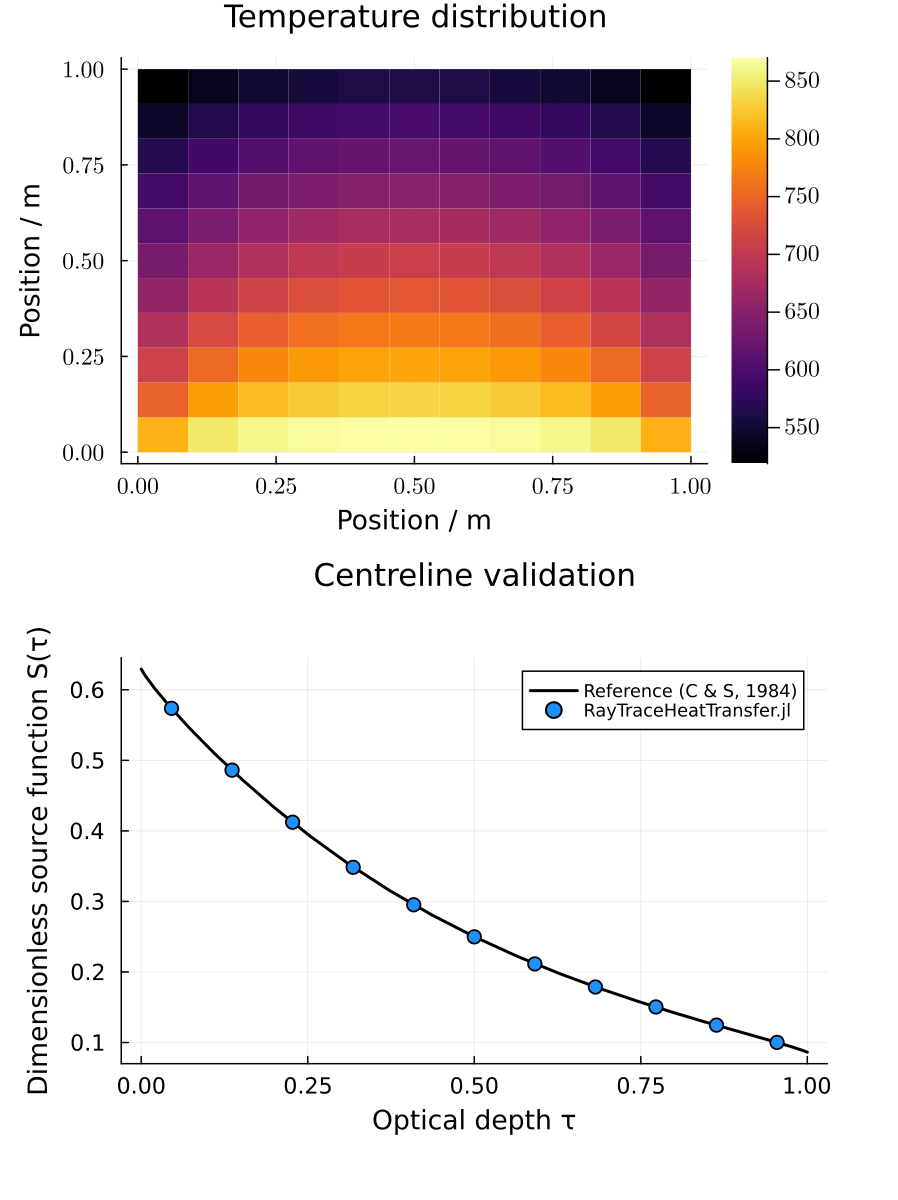

In [8]:
using Plots

# --- Top panel: solution temperature field via plotField ---
p1 = plotField(mesh1; field = :T, transparent_interfaces = true);
Plots.xlabel!(p1, "Position / m")
Plots.ylabel!(p1, "Position / m")
Plots.title!(p1, "Temperature distribution")

# Extract the centreline temperatures. The cells are stored row by row from the bottom (left to
# right within a row), so reshaping into an Ndim × Ndim matrix gives Tg_matrix[column, row].
all_temps  = [cell.T_g for cell in mesh1.fine_mesh[1]]     # gas temperature of every cell of the (single) coarse face
Tg_matrix  = reshape(all_temps, Ndim, Ndim)               # first index: column (x), second index: row (y)
centerline = Tg_matrix[div(Ndim + 1, 2), :]               # the middle column, from the hot wall upwards

# Dimensionless source function S = (T / T_hot)⁴ at the optical depth of every cell centre
S_computed  = (centerline ./ 1000.0) .^ 4                 # T_hot = 1000 K
tau_centers = range(1 / (2Ndim), 1 - 1 / (2Ndim), length = Ndim)   # τ = κ·y at the cell centres (κ = 1 m⁻¹, height 1 m)

# --- Crosbie & Schrenker (1984) analytical reference: optical depth from the hot wall, and S there ---
tau_ref = [0.0, 0.00611, 0.02037, 0.04251, 0.07216, 0.10884, 0.15194,
           0.20076, 0.25449, 0.31225, 0.37309, 0.43602, 0.50000, 0.56398,
           0.62691, 0.68775, 0.74551, 0.79924, 0.84806, 0.89116, 0.92784,
           0.95749, 0.97963, 0.99390, 1.00000]

S_ref  = [0.6293, 0.6198, 0.6017, 0.5767, 0.5460, 0.5108, 0.4724,
          0.4323, 0.3919, 0.3525, 0.3153, 0.2810, 0.2500, 0.2224,
          0.1981, 0.1768, 0.1584, 0.1424, 0.1287, 0.1171, 0.1073,
          0.0992, 0.0930, 0.0885, 0.0863]

# --- Bottom panel: centreline validation ---
p2 = Plots.plot(tau_ref, S_ref,
    linewidth = 2, color = :black, label = "Reference (C & S, 1984)",
    xlabel = "Optical depth τ",
    ylabel = "Dimensionless source function S(τ)",
    title = "Centreline validation",
    legend = :topright,
    guidefontsize = 12,
    tickfontsize = 10)

Plots.scatter!(p2, tau_centers, S_computed,
    color = :dodgerblue, markersize = 5, label = "RayTraceHeatTransfer.jl")
Plots.plot!(p2, top_margin = 8Plots.mm, bottom_margin = 8Plots.mm)

# --- Combined figure ---
Plots.plot!(p1, guidefontsize = 12, tickfontsize = 10,
            left_margin = 5Plots.mm, right_margin = 10Plots.mm)
Plots.plot(p1, p2, layout = (2, 1), size = (600, 800), dpi = 150)

In [9]:
using ConvolutionInterpolations

S_ref_itp = convolution_interpolation(tau_ref, S_ref; kernel = :b13)       # the reference as a function of optical depth
tau_edges = range(0, 1, length = Ndim + 1)                                  # optical depth at the row boundaries (κ = 1 m⁻¹, height 1 m)

# Average of the reference over the row between optical depths a and b, by the midpoint rule
function row_average(a, b; n = 1000)
    width = (b - a) / n                                                     # width of one subinterval
    total = sum(S_ref_itp(a + (k - 0.5) * width) for k in 1:n)              # the reference at every subinterval midpoint
    return total / n                                                        # its mean over the row
end

S_ref_cells = [row_average(tau_edges[j], tau_edges[j+1]) for j in 1:Ndim]   # the reference averaged over each of the 11 rows

deviation = S_computed .- S_ref_cells                                       # solution minus reference, row by row
rms_dev   = sqrt(sum(abs2, deviation) / Ndim)                               # root-mean-square deviation along the centreline
max_dev   = maximum(abs.(deviation))                                        # largest deviation along the centreline

println("Deviation from Crosbie & Schrenker: rms = ", round(rms_dev; sigdigits = 2),
        ", max = ", round(max_dev; sigdigits = 2))                          # both in units of S, which runs from 0.09 to 0.63

Deviation from Crosbie & Schrenker: rms = 0.00051, max = 0.0012


In [10]:
mesh1

RayTracingDomain2D
  geometry   1 coarse face → 121 volumes, 44 surfaces
  boundary   44 prescribed T, 121 prescribed source
  spectral   grey
  exchange   F_raw     165×165 sparse
             F_smooth  165×165 dense
  energy     6.34e-17 (relative conservation error)

In [11]:
# rms deviation of the centreline source function from the row-averaged reference (as in Step 5)
function centreline_rms(m)
    all_temps  = [cell.T_g for cell in m.fine_mesh[1]]                  # gas temperature of every cell
    centerline = reshape(all_temps, Ndim, Ndim)[div(Ndim + 1, 2), :]    # the middle column, from the hot wall upwards
    S          = (centerline ./ 1000.0) .^ 4                            # dimensionless source function
    return sqrt(sum(abs2, S .- S_ref_cells) / Ndim)                     # rms deviation from the row-averaged reference
end

few = build_mesh(Ndim)                                   # the same domain again
few(10^4; method = :exchange, verbose = false)           # 10⁴ rays instead of 10⁷: about 60 per element
smooth!(few; verbose = false)                            # reciprocity on the noisy factors
solveEquilibrium!(few, few.F_smooth; verbose = false)    # solve with the smoothed factors
println("smoothed factors: energy error = ", few.energy_error, ", rms deviation = ", centreline_rms(few))

solveEquilibrium!(few, few.F_raw; verbose = false)       # solve again, now with the raw factors
println("raw factors:      energy error = ", few.energy_error, ", rms deviation = ", centreline_rms(few))

smoothed factors: energy error = 7.856564198231085e-17, rms deviation = 0.030991542252648656
raw factors:      energy error = 7.495556468289122e-16, rms deviation = 0.08083262797331256
